# Holiday Package Prediciton

### Problem statement --
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
data = pd.read_csv("Travel.csv")

In [3]:
data.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [4]:
df = data.copy()

In [5]:
df.shape

(4888, 20)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                object
CityTier                      int64
DurationOfPitch             float64
Occupation                   object
Gender                       object
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched               object
PreferredPropertyStar       float64
MaritalStatus                object
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                  object
MonthlyIncome               float64
dtype: object

In [8]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [9]:
df.columns = [x.lower() for x in df.columns]

# Handling missing values --

In [10]:
# Age --
df['age'] = df['age'].fillna(df['age'].mean())

In [11]:
# typeofcontact
df['typeofcontact'] = df['typeofcontact'].fillna(df['typeofcontact'].mode()[0])

In [12]:
# durationofpitch
df['durationofpitch'] = df['durationofpitch'].fillna(df['durationofpitch'].mean())

In [13]:
# numberoffollowups
df['numberoffollowups'] = df['numberoffollowups'].fillna(df['numberoffollowups'].mean())

In [14]:
# preferredpropertystar
df['preferredpropertystar'] = df['preferredpropertystar'].fillna(df['preferredpropertystar'].mean())

In [15]:
# numberoftrips
df['numberoftrips'] = df['numberoftrips'].fillna(df['numberoftrips'].mean())

In [16]:
# numberofchildrenvisiting
df['numberofchildrenvisiting'] = df['numberofchildrenvisiting'].fillna(df['numberofchildrenvisiting'].mean())

In [17]:
# monthlyincome
df['monthlyincome'] = df['monthlyincome'].fillna(df['monthlyincome'].mean())

In [18]:
df.isnull().sum()

customerid                  0
prodtaken                   0
age                         0
typeofcontact               0
citytier                    0
durationofpitch             0
occupation                  0
gender                      0
numberofpersonvisiting      0
numberoffollowups           0
productpitched              0
preferredpropertystar       0
maritalstatus               0
numberoftrips               0
passport                    0
pitchsatisfactionscore      0
owncar                      0
numberofchildrenvisiting    0
designation                 0
monthlyincome               0
dtype: int64

# Data Transformation -

In [19]:
df.dtypes

customerid                    int64
prodtaken                     int64
age                         float64
typeofcontact                object
citytier                      int64
durationofpitch             float64
occupation                   object
gender                       object
numberofpersonvisiting        int64
numberoffollowups           float64
productpitched               object
preferredpropertystar       float64
maritalstatus                object
numberoftrips               float64
passport                      int64
pitchsatisfactionscore        int64
owncar                        int64
numberofchildrenvisiting    float64
designation                  object
monthlyincome               float64
dtype: object

In [20]:
df['typeofcontact'].value_counts()

typeofcontact
Self Enquiry       3469
Company Invited    1419
Name: count, dtype: int64

In [21]:
df['occupation'].value_counts()

occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [22]:
# Occupation -
df['occupation'] = df['occupation'].replace({
    'Free Lancer' : 'Salaried'
})

In [23]:
# Gender -
df['gender'].value_counts()

gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [24]:
df['gender'] = df['gender'].replace({
    'Fe Male' : 'Female'
})

In [25]:
# Product Pitched -
df['productpitched'].value_counts()

productpitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [26]:
# maritalstatus
df['maritalstatus'].unique()

array(['Single', 'Divorced', 'Married', 'Unmarried'], dtype=object)

In [27]:
df['maritalstatus'] = df['maritalstatus'].replace({
    'Unmarried' : 'Single',
    'Divorced' : 'Single'
})

In [28]:
df['designation'].unique()

array(['Manager', 'Executive', 'Senior Manager', 'AVP', 'VP'],
      dtype=object)

In [29]:
df['designation'] = df['designation'].replace({
    'Executive': 'Mid-Level',
    'Manager': 'Mid-Level',
    'Senior Manager': 'Senior',
    'AVP': 'Leadership',
    'VP': 'Leadership'
})

In [30]:
df['designation'].unique()

array(['Mid-Level', 'Senior', 'Leadership'], dtype=object)

In [31]:
df.drop(columns=['customerid'], inplace=True, axis=1)

#### Feature Extraction --

In [32]:
numerical_feature = [x for x in df.columns if df[x].dtype != "O"]
print("All numerical features are - ", len(numerical_feature))

All numerical features are -  13


In [33]:
descrite_features = [x for x in numerical_feature if len(df[x].unique()) <= 20]
print("All descrite features are - ", len(descrite_features))

All descrite features are -  10


In [34]:
continuous_features = [x for x in numerical_feature if x not in descrite_features]
print("All continuous feature : ", len(continuous_features))

All continuous feature :  3


## Train Test split --

In [35]:
x = df.drop('prodtaken', axis=1)
y = df['prodtaken']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train.shape, x_test.shape)

(3666, 18) (1222, 18)


## Column Transformer with 2 types of transformers

In [36]:
cat_feature = x.select_dtypes(include='object').columns
num_feature = x.select_dtypes(exclude='object').columns

In [37]:
# Creating processor of multiple transformation process (instanse)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

OH = OneHotEncoder(drop='first') # here "first" is used to remove first column. due to requiring (features-1) column in practical
stdsc = StandardScaler()

processor = ColumnTransformer(
    [
        ("ONEHOTENCODER", OH, cat_feature),
        ("STANDARDSCALER", stdsc, num_feature)
    ]
)

In [38]:
print(processor)

ColumnTransformer(transformers=[('ONEHOTENCODER', OneHotEncoder(drop='first'),
                                 Index(['typeofcontact', 'occupation', 'gender', 'productpitched',
       'maritalstatus', 'designation'],
      dtype='object')),
                                ('STANDARDSCALER', StandardScaler(),
                                 Index(['age', 'citytier', 'durationofpitch', 'numberofpersonvisiting',
       'numberoffollowups', 'preferredpropertystar', 'numberoftrips',
       'passport', 'pitchsatisfactionscore', 'owncar',
       'numberofchildrenvisiting', 'monthlyincome'],
      dtype='object'))])


In [39]:
x_train = processor.fit_transform(x_train)
x_test = processor.transform(x_test)

# Model Training --

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score, roc_curve

In [41]:
# Format of comparing different model's Train & Test scores ----
models = {
    'Logisic_Regression' : LogisticRegression(),
    'Decision Tree' : DecisionTreeClassifier(),
    'Random forest' : RandomForestClassifier()
}


for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    # "Train prediction ----------"
    train_accurecy = accuracy_score(train_pred, y_train)
    train_f1_score = f1_score(train_pred, y_train, average='weighted')
    train_precision = precision_score(train_pred, y_train)
    train_recall = recall_score(train_pred, y_train)
    train_roc_auc = roc_auc_score(train_pred, y_train)
    
    # "test prediction ----------"
    test_accurecy = accuracy_score(test_pred, y_test)
    test_f1_score = f1_score(test_pred, y_test, average='weighted')
    test_precision = precision_score(test_pred, y_test)
    test_recall = recall_score(test_pred, y_test)
    test_roc_auc = roc_auc_score(test_pred, y_test)

    print(list(models.keys())[i])

    print('Model performance for Train set')
    print('- Accuracy: {:.4f}'.format(train_accurecy))
    print('- F1 score: {:.4f}'.format(train_f1_score))
    print('- Precision: {:.4f}'.format(train_precision))
    print('- Recall: {:.4f}'.format(train_recall))
    print('- Roc Auc Score: {:.4f}'.format(train_roc_auc))
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Accuracy: {:.4f}".format(test_accurecy))
    print('- F1 score: {:.4f}'.format(test_f1_score))
    print('- Precision: {:.4f}'.format(test_precision))
    print('- Recall: {:.4f}'.format(test_recall))
    print('- Roc Auc Score: {:.4f}'.format(test_roc_auc))

    
    print('='*35)
    print('\n')

Logisic_Regression
Model performance for Train set
- Accuracy: 0.8380
- F1 score: 0.8663
- Precision: 0.2812
- Recall: 0.6782
- Roc Auc Score: 0.7649
----------------------------------
Model performance for Test set
- Accuracy: 0.8502
- F1 score: 0.8738
- Precision: 0.3184
- Recall: 0.6961
- Roc Auc Score: 0.7802


Decision Tree
Model performance for Train set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8879
- F1 score: 0.8872
- Precision: 0.7085
- Recall: 0.6870
- Roc Auc Score: 0.8107


Random forest
Model performance for Train set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9141
- F1 score: 0.9235
- Precision: 0.5561
- Recall: 0.9538
- Roc Auc Score: 0.9316




# Hyperparameter Tuning

In [42]:
rf_param = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : [10, 20, 30, 40, 50],
    'max_features' : [2, 4, 6, 7],
    'n_estimators' : [50, 100, 200, 400, 800]
}

In [43]:
randomCv = [
    ("RF", RandomForestClassifier(), rf_param)
]

In [44]:
# It's a proccess of efficiently use different models ----
from sklearn.model_selection import RandomizedSearchCV

best_model = {}

for name, model, params in randomCv:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        cv=5,
        n_jobs=-1,
        random_state=42,
        n_iter=100,
        verbose=2
    )
    random.fit(x_train, y_train)
    best_model[name] = random.best_params_


for val in best_model:
    print(f"For {val} model, best parameter would be - {best_model[val]}")
    print("*"*20)
    

Fitting 5 folds for each of 100 candidates, totalling 500 fits
For RF model, best parameter would be - {'n_estimators': 800, 'max_features': 7, 'max_depth': 40, 'criterion': 'gini'}
********************


In [45]:
models = {
    "RF" : RandomForestClassifier(
        n_estimators=400,
        max_features=7,
        max_depth=40,
        criterion='gini'
    )
}


for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    # "Train prediction ----------"
    train_accurecy = accuracy_score(train_pred, y_train)
    train_f1_score = f1_score(train_pred, y_train, average='weighted')
    train_precision = precision_score(train_pred, y_train)
    train_recall = recall_score(train_pred, y_train)
    train_roc_auc = roc_auc_score(train_pred, y_train)
    
    # "test prediction ----------"
    test_accurecy = accuracy_score(test_pred, y_test)
    test_f1_score = f1_score(test_pred, y_test, average='weighted')
    test_precision = precision_score(test_pred, y_test)
    test_recall = recall_score(test_pred, y_test)
    test_roc_auc = roc_auc_score(test_pred, y_test)

    print(list(models.keys())[i])

    print('Model performance for Train set')
    print('- Accuracy: {:.4f}'.format(train_accurecy))
    print('- F1 score: {:.4f}'.format(train_f1_score))
    print('- Precision: {:.4f}'.format(train_precision))
    print('- Recall: {:.4f}'.format(train_recall))
    print('- Roc Auc Score: {:.4f}'.format(train_roc_auc))
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Accuracy: {:.4f}".format(test_accurecy))
    print('- F1 score: {:.4f}'.format(test_f1_score))
    print('- Precision: {:.4f}'.format(test_precision))
    print('- Recall: {:.4f}'.format(test_recall))
    print('- Roc Auc Score: {:.4f}'.format(test_roc_auc))

    
    print('='*35)
    print('\n')

RF
Model performance for Train set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9223
- F1 score: 0.9289
- Precision: 0.6143
- Recall: 0.9384
- Roc Auc Score: 0.9292




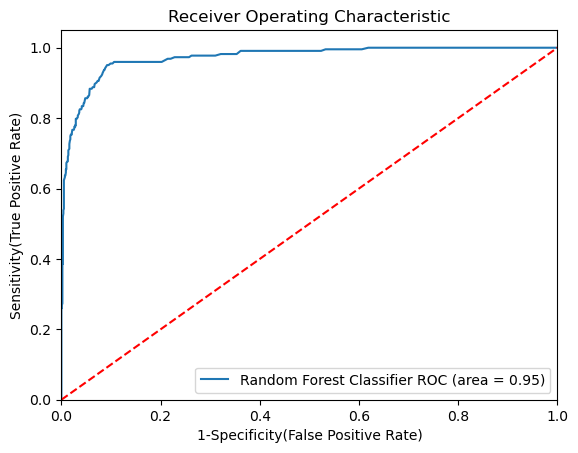

In [46]:
from sklearn.metrics import roc_auc_score, roc_curve

auc_model = [{
    "labels" : "Random Forest Classifier",
    "model" : RandomForestClassifier(
        n_estimators=400,
        max_features=7,
        max_depth=40,
        criterion='gini'
    ),
    "auc_score" : 0.9459
}]

for algo in auc_model:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # Train the model

    fpr, tpr, threshold = roc_curve(y_test, model.predict_proba(x_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{algo['labels']} ROC (area = {algo['auc_score']:.2f})")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
# plt.savefig("auc.png")
plt.show() 